## Implementing Simple ChatBot Using LangGraph

In [14]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

from typing import Annotated
from langgraph.graph.message import add_messages


In [15]:
class State(TypedDict):
    messages:Annotated[list,add_messages] 

In [16]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [17]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    model="openai/gpt-oss-120b",
    model_provider="groq"
)

llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002150624FBB0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000215063AC640>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [18]:
def  SuperBot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [22]:
graph = StateGraph(State)

graph.add_node("superbot",SuperBot)

graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

graph_builder = graph.compile()



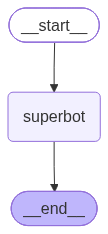

In [23]:
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [26]:
res = graph_builder.invoke({"messages":"Hie My Name is Rajat , Can you please give A joke"})
res

{'messages': [HumanMessage(content='Hie My Name is Rajat , Can you please give A joke', additional_kwargs={}, response_metadata={}, id='411c0b0d-8a01-4f78-8ab9-fe61cbafa0f3'),
  AIMessage(content='Sure thing, Rajat! Here’s a light‑hearted one for you:\n\n**Why did the scarecrow become a successful motivational speaker?**  \nBecause he was outstanding in his field! 😄', additional_kwargs={'reasoning_content': 'The user asks for a joke. Simple. Provide a joke. Probably friendly.'}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 85, 'total_tokens': 151, 'completion_time': 0.136052791, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.01751758, 'prompt_tokens_details': None, 'queue_time': 0.485160378, 'total_time': 0.153570371}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_ca5edfaab2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0473a-4d10-7ee2-9a0d-ec2

In [28]:
for event in graph_builder.stream({"messages":"can you give me Python code of Basics Calculator"},stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='can you give me Python code of Basics Calculator', additional_kwargs={}, response_metadata={}, id='a44749f7-1486-4c81-87dd-76a76543ec62')]}
{'messages': [HumanMessage(content='can you give me Python code of Basics Calculator', additional_kwargs={}, response_metadata={}, id='a44749f7-1486-4c81-87dd-76a76543ec62'), AIMessage(content='Sure! Below is a simple **basic calculator** written in Python.  \nIt supports the four primary arithmetic operations (addition, subtraction, multiplication, division) and runs in a loop so you can perform multiple calculations until you decide to quit.\n\n```python\n#!/usr/bin/env python3\n"""\nBasic Calculator\n----------------\nA tiny command‑line calculator that can add, subtract, multiply, and divide numbers.\n"""\n\ndef add(a, b):\n    return a + b\n\ndef sub(a, b):\n    return a - b\n\ndef mul(a, b):\n    return a * b\n\ndef div(a, b):\n    # Guard against division by zero\n    if b == 0:\n        raise ZeroDivision